In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# =============================================
# 1. 데이터 로드
# =============================================
# 원본 데이터 (DDQN에 넣은 선택된 변수들)
df = pd.read_csv("../../data/processed/data_vif.csv", index_col=0)
# Risk_Label 인코딩
# 문자열이면 변환, 이미 숫자면 그대로
if df["Risk_Label"].dtype == object:
    df["Risk_Label"] = df["Risk_Label"].map({
        "Low Risk": 0,
        "High Risk": 1
    })
    print("Risk_Label 인코딩 완료")
    print(df["Risk_Label"].value_counts())

# DDQN test 예측값
df_pred = pd.read_csv("../../data/processed/data_DDQN_predicted.csv")
# 컬럼: date, predicted_action

print(f"원본 데이터: {len(df)}개")
print(f"Test 예측값: {len(df_pred)}개")
print(df_pred.head())

# =============================================
# 2. 데이터 분할
# =============================================
n_total = len(df)
n_train = int(n_total * 0.50)   # 2054
n_valid = int(n_total * 0.30)   # 1232
# test = 나머지 822

df_valid = df.iloc[n_train : n_train + n_valid].copy()
df_test  = df.iloc[n_train + n_valid :].copy()
df_pred_valid = df_pred.iloc[n_train : n_train + n_valid].copy()
df_pred_test  = df_pred.iloc[n_train + n_valid :].copy()

print(f"\nValid set: {len(df_valid)}개")
print(f"Test set:  {len(df_test)}개")

Risk_Label 인코딩 완료
Risk_Label
0    3672
1     436
Name: count, dtype: int64
원본 데이터: 4108개
Test 예측값: 4108개
         Date  Predicted_Action
0  2009-04-17                 0
1  2009-04-20                 1
2  2009-04-21                 1
3  2009-04-22                 0
4  2009-04-23                 0

Valid set: 1232개
Test set:  822개



Valid action 분포: 0=1073, 1=159
Test action 분포:  0=734, 1=88
Test 길이 일치: True

Grid Search 결과 (Valid)
최적 b1 = 0.050
최적 b2 = 0.200
Valid 위반율   = 0.0500
Valid p-value  = 0.9583
기대 위반율    = 0.0500


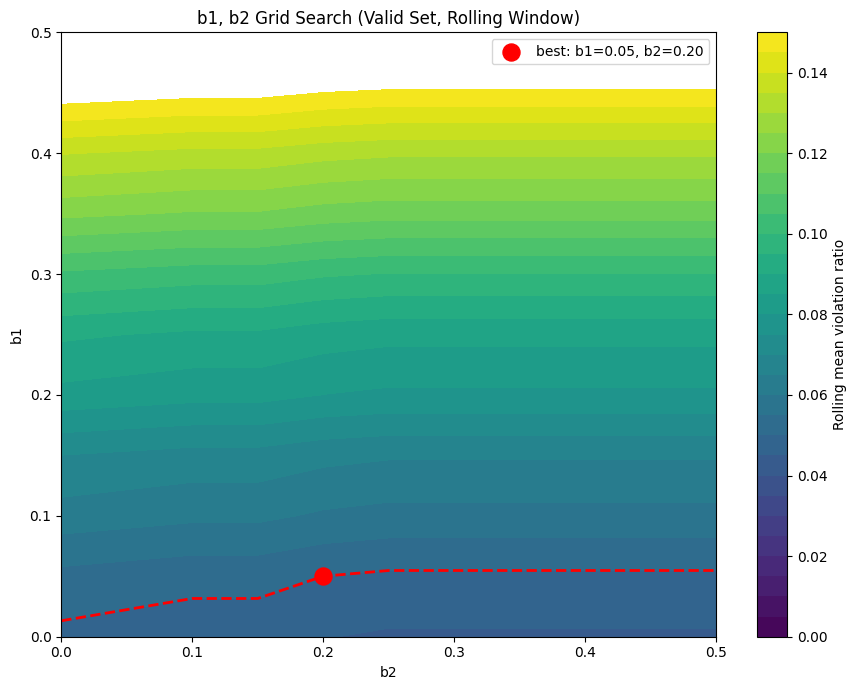


Test Set 최종 평가
기대 위반 횟수: 41.1회 (822일 × 5%)

[원래 GJR-GARCH VaR]
  위반 횟수:  36회
  위반 비율:  0.0438
  Kupiec LR:  0.6940
  p-value:    0.4048
  판정:       Accept H0

[조정된 VaR_ML (DDQN, b1=0.05, b2=0.20)]
  위반 횟수:  36회
  위반 비율:  0.0438
  Kupiec LR:  0.6940
  p-value:    0.4048
  판정:       Accept H0

[비교 요약]
  원래 VaR 위반:    36회 → Accept H0
  조정 VaR 위반:    36회  → Accept H0
  개선 여부: 위반 횟수 증가 ✗


In [29]:
# =============================================
# Kupiec test
# =============================================
def kupiec_test(violations, n_obs, alpha=0.05):
    T = int(violations)
    N = int(n_obs)
    if T == 0 or T == N:
        return np.nan, np.nan, "계산불가"
    p_hat = T / N
    lr_stat = -2 * (
        T * np.log(alpha / p_hat) +
        (N - T) * np.log((1 - alpha) / (1 - p_hat))
    )
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)
    decision = "Accept H0" if p_value >= 0.05 else "Reject H0"
    return float(lr_stat), float(p_value), decision

# =============================================
# 3. 필요 변수 추출
# =============================================
# Valid: Risk_Label을 action으로 사용
var_valid    = df_valid["GJR_VaR_5_t1"].to_numpy(dtype=float)
ret_valid    = df_valid["return(%)"].to_numpy(dtype=float)
action_valid = df_valid["Risk_Label"].to_numpy(dtype=int)

# Test: DDQN 예측값을 action으로 사용
var_test     = df_test["GJR_VaR_5_t1"].to_numpy(dtype=float)
ret_test     = df_test["return(%)"].to_numpy(dtype=float)
action_test  = df_pred_test["Predicted_Action"].to_numpy(dtype=int)

# 검증
print(f"\nValid action 분포: "
      f"0={(action_valid==0).sum()}, "
      f"1={(action_valid==1).sum()}")
print(f"Test action 분포:  "
      f"0={(action_test==0).sum()}, "
      f"1={(action_test==1).sum()}")
print(f"Test 길이 일치: {len(action_test) == len(df_test)}")

# =============================================
# 4. b1, b2 grid search (valid에서)
# =============================================
b1_grid     = np.linspace(0.0, 0.5, 11)
b2_grid     = np.linspace(0.0, 0.5, 11)
window_size = 100
n_valid_len = len(df_valid)

coverage      = np.zeros((len(b1_grid), len(b2_grid)))
pvalue_matrix = np.zeros((len(b1_grid), len(b2_grid)))
loss_matrix   = np.zeros((len(b1_grid), len(b2_grid)))

for i, b1 in enumerate(b1_grid):
    for j, b2 in enumerate(b2_grid):

        # VaR 조정
        var_ml = np.where(
            action_valid == 0,
            var_valid * (1.0 - b1),   # Low Risk → 완화
            var_valid * (1.0 + b2)    # High Risk → 강화
        )

        # rolling window 평균 위반율
        rolling_ratios = []
        for start in range(n_valid_len - window_size + 1):
            end = start + window_size
            ratio = (ret_valid[start:end] < var_ml[start:end]).mean()
            rolling_ratios.append(ratio)

        mean_ratio = float(np.mean(rolling_ratios))
        coverage[i, j]    = mean_ratio
        loss_matrix[i, j] = abs(mean_ratio - 0.05)

        # Kupiec test (valid 전체)
        T_valid = int((ret_valid < var_ml).sum())
        _, pval, _ = kupiec_test(T_valid, n_valid_len)
        pvalue_matrix[i, j] = pval if not np.isnan(pval) else 0.0

# 최적 선택: Kupiec p-value 최대
best_idx    = np.unravel_index(
    np.argmax(pvalue_matrix), pvalue_matrix.shape
)
b1_best     = float(b1_grid[best_idx[0]])
b2_best     = float(b2_grid[best_idx[1]])
best_ratio  = float(coverage[best_idx])
best_pvalue = float(pvalue_matrix[best_idx])

print("\n" + "="*50)
print("Grid Search 결과 (Valid)")
print("="*50)
print(f"최적 b1 = {b1_best:.3f}")
print(f"최적 b2 = {b2_best:.3f}")
print(f"Valid 위반율   = {best_ratio:.4f}")
print(f"Valid p-value  = {best_pvalue:.4f}")
print(f"기대 위반율    = 0.0500")

# =============================================
# 5. Contour plot
# =============================================
B2, B1 = np.meshgrid(b2_grid, b1_grid)

plt.figure(figsize=(9, 7))
levels = np.linspace(0.0, 0.15, 31)
cont = plt.contourf(
    B2, B1, coverage,
    levels=levels, cmap="viridis"
)
plt.colorbar(cont, label="Rolling mean violation ratio")

# 0.05 등위선 표시
plt.contour(
    B2, B1, coverage,
    levels=[0.05],
    colors="red", linewidths=2, linestyles="--"
)

# 최적점 표시
plt.scatter(
    [b2_best], [b1_best],
    c="red", s=150, zorder=5,
    label=f"best: b1={b1_best:.2f}, b2={b2_best:.2f}"
)
plt.xlabel("b2")
plt.ylabel("b1")
plt.title("b1, b2 Grid Search (Valid Set, Rolling Window)")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================
# 6. Test set 최종 평가
# =============================================
n_test = len(df_test)

# 원래 GJR VaR (조정 없음)
T_orig = int((ret_test < var_test).sum())
lr_o, pv_o, dec_o = kupiec_test(T_orig, n_test)

# 조정된 VaR_ML (DDQN 예측 + b1*, b2*)
var_ml_test = np.where(
    action_test == 0,
    var_test * (1.0 - b1_best),
    var_test * (1.0 + b2_best)
)
T_ml = int((ret_test < var_ml_test).sum())
lr_m, pv_m, dec_m = kupiec_test(T_ml, n_test)

print("\n" + "="*50)
print("Test Set 최종 평가")
print("="*50)
print(f"기대 위반 횟수: {n_test * 0.05:.1f}회 ({n_test}일 × 5%)")

print(f"\n[원래 GJR-GARCH VaR]")
print(f"  위반 횟수:  {T_orig}회")
print(f"  위반 비율:  {T_orig/n_test:.4f}")
print(f"  Kupiec LR:  {lr_o:.4f}")
print(f"  p-value:    {pv_o:.4f}")
print(f"  판정:       {dec_o}")

print(f"\n[조정된 VaR_ML (DDQN, b1={b1_best:.2f}, b2={b2_best:.2f})]")
print(f"  위반 횟수:  {T_ml}회")
print(f"  위반 비율:  {T_ml/n_test:.4f}")
print(f"  Kupiec LR:  {lr_m:.4f}")
print(f"  p-value:    {pv_m:.4f}")
print(f"  판정:       {dec_m}")

print(f"\n[비교 요약]")
print(f"  원래 VaR 위반:    {T_orig}회 → {dec_o}")
print(f"  조정 VaR 위반:    {T_ml}회  → {dec_m}")
print(f"  개선 여부: {'위반 횟수 감소 ✓' if T_ml < T_orig else '위반 횟수 증가 ✗'}")